Overall Minimum Pixel Intensity: 0
Overall Maximum Pixel Intensity: 255
Overall Maximum Height: 1446
Overall Minimum Height: 167
Overall Maximum Width: 1375
Overall Minimum Width: 175
Height Bounds: 53 : 1373
Width Bounds: 80 : 1346
Starting to scan images in './pg_dataset/pg_dataset_combined'...
Scan complete. Processed 1426 images.


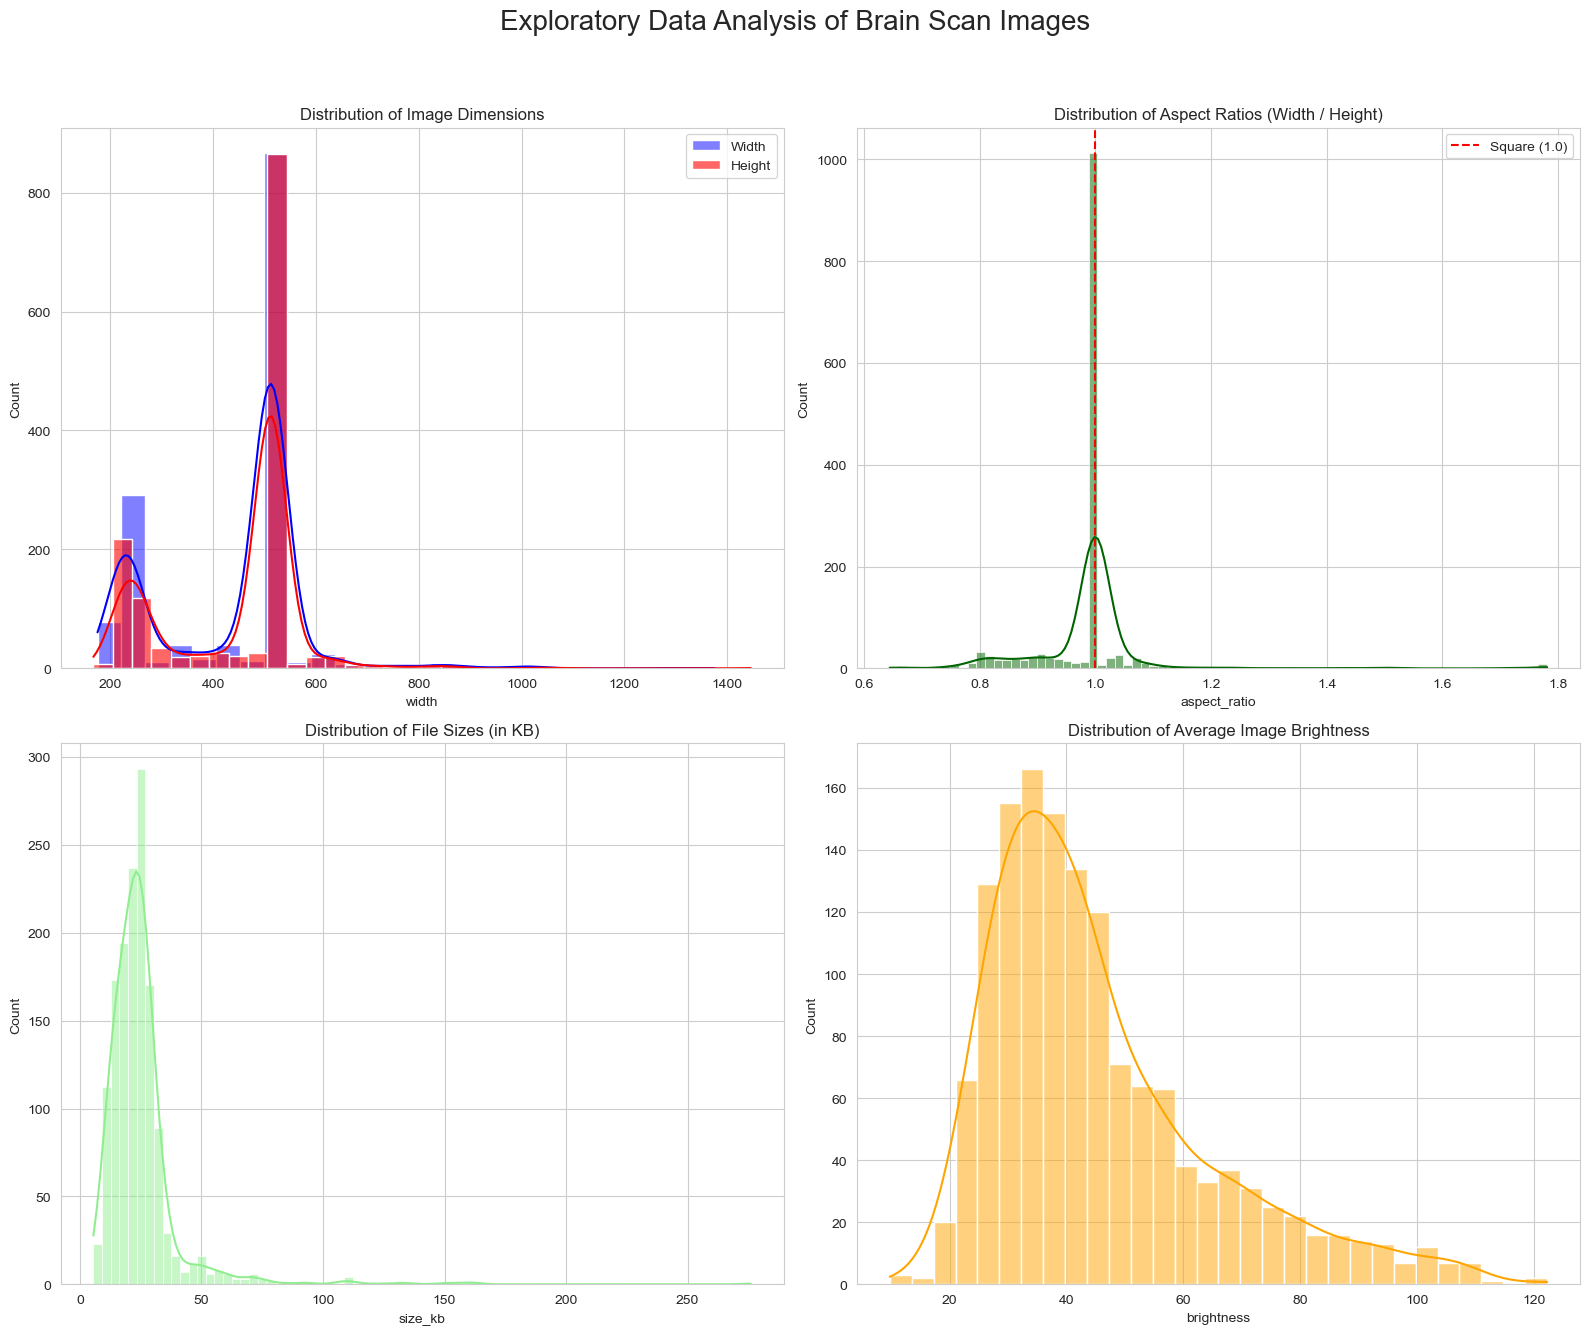

Starting data preprocessing pipeline.

Loading all images into memory
  - Loaded 1426 images successfully.

Computing pre-processing statistics...

BEFORE PREPROCESSING - IMAGE STATISTICS BY CATEGORY

YES Class:
  Image Count:                    926
  Pixel Intensity Range:          0 - 255
  Height Range (pixels):          167 - 665
  Width Range (pixels):           175 - 640
  Average Height:                 502.97
  Average Width:                  500.74
  Height Bounds: <224: 1 | ≥224: 925
  Width Bounds:  <224: 6 | ≥224: 920

NO Class:
  Image Count:                    500
  Pixel Intensity Range:          0 - 255
  Height Range (pixels):          198 - 1446
  Width Range (pixels):           200 - 1375
  Average Height:                 330.49
  Average Width:                  325.33
  Height Bounds: <224: 52 | ≥224: 448
  Width Bounds:  <224: 74 | ≥224: 426

Applying duplicate detection to YES class only...
  - Found and marked 70 duplicate images for removal in YES class.

Checki

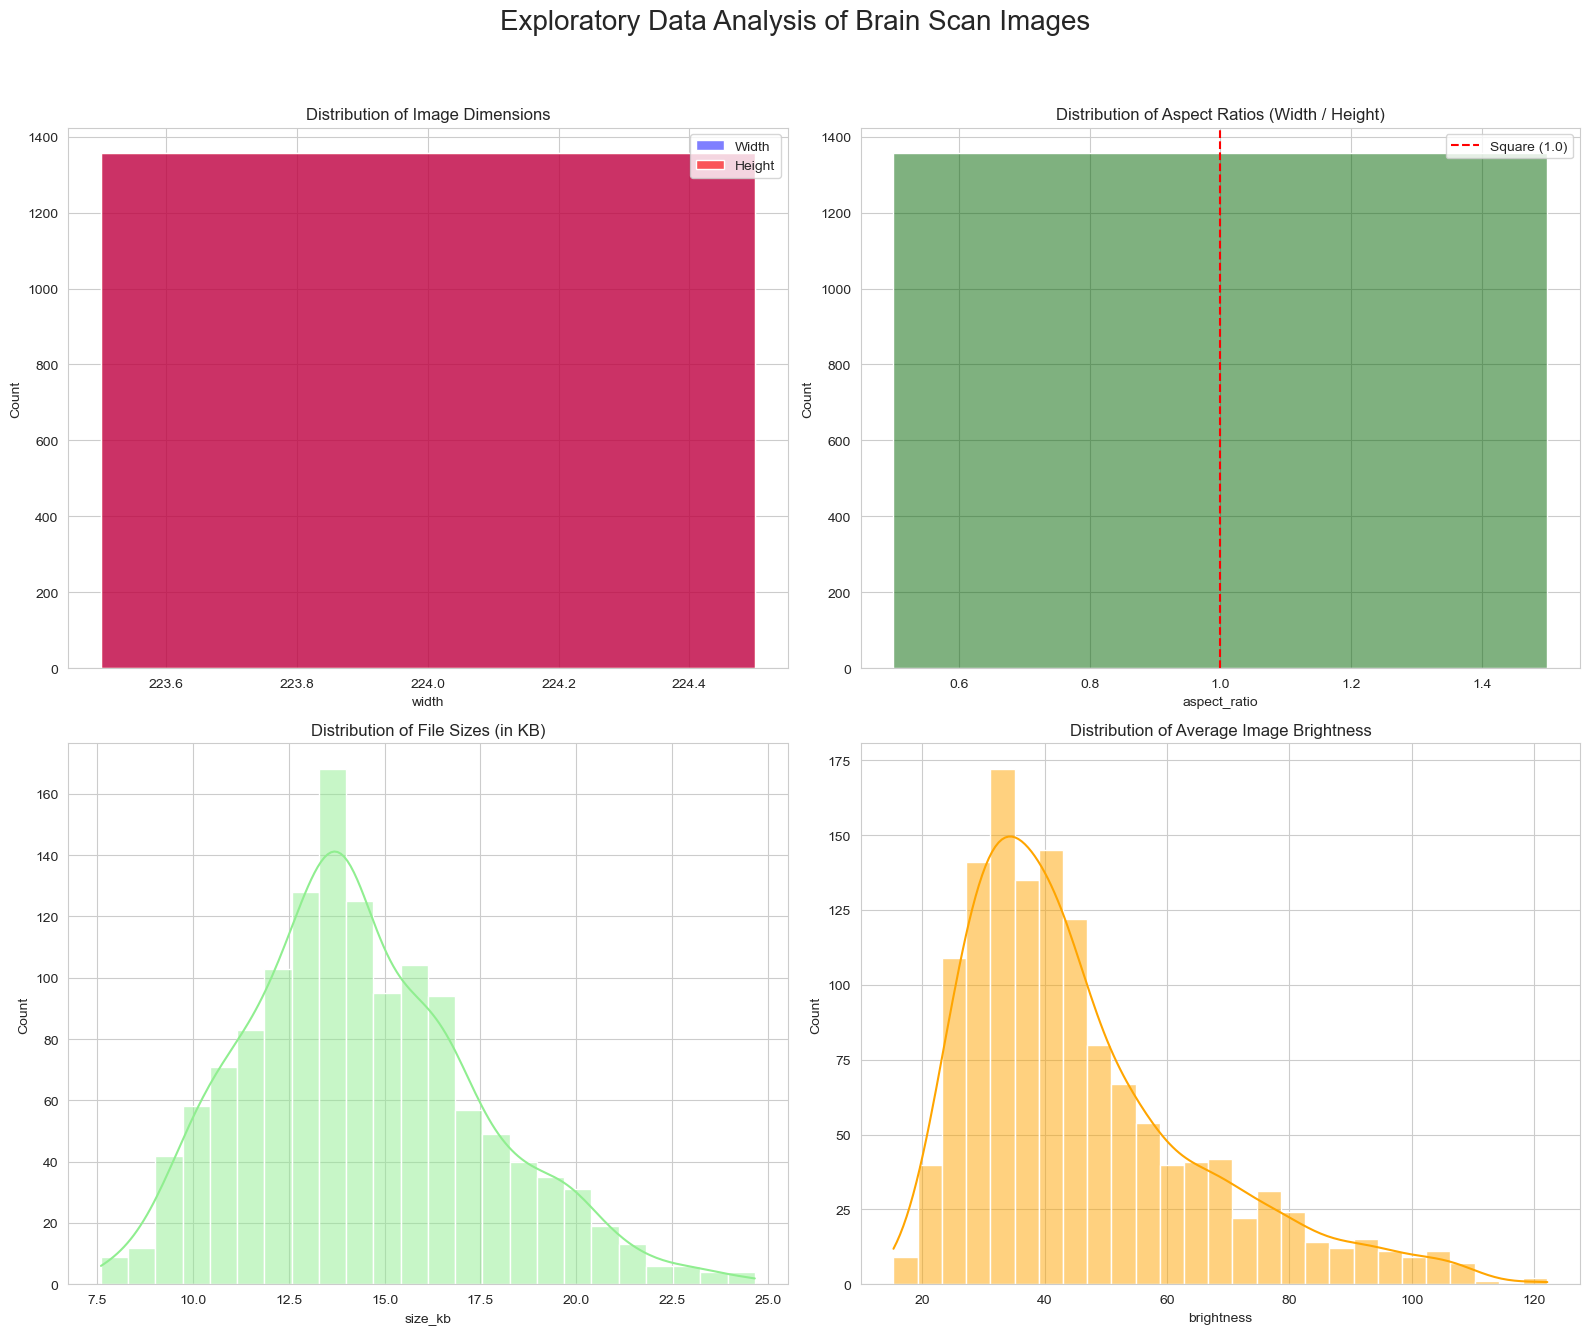

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
import imagehash
from collections import defaultdict
import shutil
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

"""The order in the file is:
Imports
Constants
Function definitions (preprocess_dataset(), run_analytics(), get_stats(), plot_distributions())
Main execution block (if __name__ == '__main__':) - calls the functions"""

DATASET_DIR = DATA_DIR = './pg_dataset/pg_dataset_combined'
OUTPUT_DIR = 'brain_tumor_data_preprocessed_all'
# Data Quality Checks
SIMILARITY_THRESHOLD = 2  # Perceptual hash distance for duplicate detection (0-64 range, lower = stricter)
"""The imagehash.phash() function creates a perceptual hash (a 64-bit fingerprint). When you subtract two hashes with the - operator, 
it calculates the Hamming distance (number of differing bits). This distance ranges from 0-64.
So the code is simply: "If the Hamming distance between two image hashes is 5 or less, consider them duplicates."""
Z_SCORE_THRESHOLD = 5.0  # Standard deviations from mean brightness to flag as outlier
LOW_VARIANCE_THRESHOLD = 10  # Minimum pixel variance to avoid blank/corrupted images
# Image Preprocessing
TARGET_SIZE = (224, 224)  # Standard CNN input size for model compatibility
CROP_TO_SQUARE_RATIO = 1.1  # Max width-to-height ratio before cropping to square 


def compute_image_stats(dataset_dir, class_name):
    """Compute and return detailed statistics for a specific class"""
    stats = {
        'class': class_name,
        'count': 0,
        'min_pixel': 255,
        'max_pixel': 0,
        'min_height': 99999,
        'max_height': 0,
        'min_width': 99999,
        'max_width': 0,
        'height_below_224': 0,
        'height_above_224': 0,
        'width_below_224': 0,
        'width_above_224': 0,
        'avg_height': 0,
        'avg_width': 0,
        'heights': [],
        'widths': []
    }
    
    class_dir = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_dir):
        return stats
    
    for filename in os.listdir(class_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(class_dir, filename)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
            if image is not None:
                h, w = image.shape
                stats['count'] += 1
                stats['min_pixel'] = min(stats['min_pixel'], np.min(image))
                stats['max_pixel'] = max(stats['max_pixel'], np.max(image))
                stats['min_height'] = min(stats['min_height'], h)
                stats['max_height'] = max(stats['max_height'], h)
                stats['min_width'] = min(stats['min_width'], w)
                stats['max_width'] = max(stats['max_width'], w)
                stats['heights'].append(h)
                stats['widths'].append(w)
                
                if h < 224:
                    stats['height_below_224'] += 1
                else:
                    stats['height_above_224'] += 1
                if w < 224:
                    stats['width_below_224'] += 1
                else:
                    stats['width_above_224'] += 1
    
    if stats['count'] > 0:
        stats['avg_height'] = np.mean(stats['heights'])
        stats['avg_width'] = np.mean(stats['widths'])
    
    return stats


def print_stats_report(stats_dict, stage_name):
    """Print a formatted statistics report for each class"""
    print(f"\n{'='*80}")
    print(f"{stage_name.upper()}")
    print(f"{'='*80}\n")
    
    for class_name in ['yes', 'no']:
        stats = stats_dict[class_name]
        if stats['count'] == 0:
            print(f"{class_name.upper()}: No images found\n")
            continue
        
        print(f"{class_name.upper()} Class:")
        print(f"  Image Count:                    {stats['count']:,}")
        print(f"  Pixel Intensity Range:          {stats['min_pixel']} - {stats['max_pixel']}")
        print(f"  Height Range (pixels):          {stats['min_height']} - {stats['max_height']}")
        print(f"  Width Range (pixels):           {stats['min_width']} - {stats['max_width']}")
        print(f"  Average Height:                 {stats['avg_height']:.2f}")
        print(f"  Average Width:                  {stats['avg_width']:.2f}")
        print(f"  Height Bounds: <224: {stats['height_below_224']:,} | ≥224: {stats['height_above_224']:,}")
        print(f"  Width Bounds:  <224: {stats['width_below_224']:,} | ≥224: {stats['width_above_224']:,}")
        print()


def preprocess_dataset():
    print("Starting data preprocessing pipeline.\n")
    in_memory_images = []  # Container to store all images and metadata
    print("Loading all images into memory")
    for class_name in ['yes', 'no']:  # Iterate through tumor/no-tumor classes
        class_dir = os.path.join(DATASET_DIR, class_name)  # Build class directory path
        if not os.path.isdir(class_dir):  # Verify directory exists
            print(f"Warning: Directory not found for class '{class_name}'. Skipping.")
            continue
        
        for filename in os.listdir(class_dir):  # Loop through all files in directory
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):  # Filter for image files only
                file_path = os.path.join(class_dir, filename)  # Build full file path
                try:
                    # image = cv2.imread(file_path) is where the original JPEG file is 
                    # converted from disk storage into memory as a NumPy array.
                    image = cv2.imread(file_path)  # Load image into memory
                    if image is not None:  # Verify image loaded successfully
                        in_memory_images.append({  # Store image with metadata
                            'path': file_path,
                            'class': class_name,
                            'image': image
                        })
                    else:
                        print(f"  - Warning: Could not read (corrupted?) file: {file_path}")
                except Exception as e:  # Catch unexpected errors during loading
                    print(f"  - Warning: Error loading {file_path}: {e}")
    print(f"  - Loaded {len(in_memory_images)} images successfully.\n")

    # Compute and display BEFORE preprocessing stats
    print("Computing pre-processing statistics...")
    before_stats = {
        'yes': compute_image_stats(DATASET_DIR, 'yes'),
        'no': compute_image_stats(DATASET_DIR, 'no')
    }
    print_stats_report(before_stats, "BEFORE PREPROCESSING - IMAGE STATISTICS BY CATEGORY")

    if not in_memory_images:
        print("  - No images to process. Skipping duplicate check.\n")
        images_after_dedupe = []
    else:
        # Separate images by class
        yes_images = [data for data in in_memory_images if data['class'] == 'yes']
        no_images = [data for data in in_memory_images if data['class'] == 'no']
        
        # Apply deduplication only to 'yes' class
        print("Applying duplicate detection to YES class only...")
        images_by_path = {data['path']: data for data in yes_images}
        
        if yes_images:
            # Compute perceptual hashes for YES class images
            image_hashes = {}
            for data in yes_images:
                try:
                    # Convert OpenCV BGR to RGB for Pillow/imagehash
                    image_rgb = cv2.cvtColor(data['image'], cv2.COLOR_BGR2RGB)
                    pil_image = Image.fromarray(image_rgb)
                    image_hashes[data['path']] = imagehash.phash(pil_image)
                except Exception as e:
                    print(f"  - Warning: Could not hash {data['path']}: {e}")

            # Find all pairs of visually similar images
            duplicate_pairs = []
            paths = list(image_hashes.keys())
            for i in range(len(paths)):
                for j in range(i + 1, len(paths)):
                    path1 = paths[i]
                    path2 = paths[j]
                    distance = image_hashes[path1] - image_hashes[path2]
                    if distance <= SIMILARITY_THRESHOLD:
                        duplicate_pairs.append((path1, path2))

            # Use a graph to find connected components of duplicates
            G = nx.Graph()
            G.add_edges_from(duplicate_pairs)
            connected_components = list(nx.connected_components(G))

            paths_to_remove = set()
            # For each group of duplicates, find the one with the highest resolution
            for component in connected_components:
                if len(component) > 1:  # A group of <= 2 similar images
                    best_path = ""
                    max_resolution = -1
                    
                    # Find the "best" image (ie. largest) in the component
                    for path in component:
                        image_data = images_by_path[path]['image']
                        resolution = image_data.shape[0] * image_data.shape[1]
                        if resolution > max_resolution:
                            max_resolution = resolution
                            best_path = path
                    
                    for path in component:
                        if path != best_path:
                            paths_to_remove.add(path)
            
            yes_images_after_dedupe = [data for data in yes_images if data['path'] not in paths_to_remove]
            num_duplicates = len(yes_images) - len(yes_images_after_dedupe)
            print(f"  - Found and marked {num_duplicates} duplicate images for removal in YES class.\n")
        else:
            yes_images_after_dedupe = []
        
        # Combine deduplicated YES images with all NO images
        images_after_dedupe = yes_images_after_dedupe + no_images
    
    print("Checking for outliers.")
    # Z-Score for brightness - apply to both YES and NO classes
    brightness_values = []
    brightness_by_data = {}
    
    for data in images_after_dedupe:
        gray_image = cv2.cvtColor(data['image'], cv2.COLOR_BGR2GRAY)
        brightness = np.mean(gray_image)
        brightness_values.append(brightness)
        brightness_by_data[data['path']] = brightness
    
    brightness_values = np.array(brightness_values)
    mean_brightness = np.mean(brightness_values) if len(brightness_values) > 0 else 0
    std_brightness = np.std(brightness_values) if len(brightness_values) > 0 else 1
    
    outliers_to_remove = set()
    
    for data in images_after_dedupe:
        brightness = brightness_by_data[data['path']]
        # Check Z-score
        z_score = (brightness - mean_brightness) / std_brightness if std_brightness > 0 else 0
        if abs(z_score) > Z_SCORE_THRESHOLD:
            outliers_to_remove.add(data['path'])
            print(f"  - Outlier (Z-Score): {data['path']} (Z-Score: {z_score:.2f})")
            continue
            
        # Check blank images - LOW_VARIANCE_THRESHOLD only for YES class
        if data['class'] == 'yes':
            gray_image = cv2.cvtColor(data['image'], cv2.COLOR_BGR2GRAY)
            if np.std(gray_image) < LOW_VARIANCE_THRESHOLD:
                outliers_to_remove.add(data['path'])
                print(f"  - Outlier (Low Variance): {data['path']}")

    images_after_outliers = [data for data in images_after_dedupe if data['path'] not in outliers_to_remove]
    num_outliers = len(images_after_dedupe) - len(images_after_outliers)
    print(f"  - Found and marked {num_outliers} outlier images for removal.\n")


    # Resize and write cleaned data to new directory
    print("Resizing and writing cleaned images to new directory")
    
    # Clear and create the output directories
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR) # Deletes the old directory and its contents
    os.makedirs(os.path.join(OUTPUT_DIR, 'yes'))
    os.makedirs(os.path.join(OUTPUT_DIR, 'no'))

    for data in images_after_outliers:
        try:
            image_to_process = data['image']
            h, w, _ = image_to_process.shape

            # Crop the image to a square if it's not already close to one
            if w > h * CROP_TO_SQUARE_RATIO:
                # Width is significantly larger, crop the center horizontally
                start_x = (w - h) // 2
                image_to_process = image_to_process[:, start_x:start_x + h]
            # Resize the (potentially cropped) image
            resized_image = cv2.resize(image_to_process, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            
            # Create the new path and save the image
            filename = os.path.basename(data['path'])
            output_path = os.path.join(OUTPUT_DIR, data['class'], filename)
            cv2.imwrite(output_path, resized_image)
        except Exception as e:
            print(f"  - Warning: Could not save {data['path']}. Error: {e}")

    print(f"  - Successfully wrote {len(images_after_outliers)} preprocessed images to '{OUTPUT_DIR}'.\n")
    
    # Compute and display AFTER preprocessing stats
    print("Computing post-processing statistics...")
    after_stats = {
        'yes': compute_image_stats(OUTPUT_DIR, 'yes'),
        'no': compute_image_stats(OUTPUT_DIR, 'no')
    }
    print_stats_report(after_stats, "AFTER PREPROCESSING - IMAGE STATISTICS BY CATEGORY")
    
    # Count and print category distribution after preprocessing
    print(f"{'='*80}")
    print("PREPROCESSING SUMMARY - IMAGE COUNT BY CATEGORY")
    print(f"{'='*80}\n")
    category_counts = defaultdict(int)
    for data in images_after_outliers:
        category_counts[data['class']] += 1
    
    yes_count = category_counts['yes']
    no_count = category_counts['no']
    total_count = yes_count + no_count
    
    print(f"Brain Tumor (YES):     {yes_count:,} images")
    print(f"No Tumor (NO):         {no_count:,} images")
    print(f"Total:                 {total_count:,} images")
    print(f"YES Percentage:        {(yes_count/total_count*100):.2f}%")
    print(f"NO Percentage:         {(no_count/total_count*100):.2f}%")
    print(f"{'='*80}\n")
    
    print("Pipeline finished successfully!")

def run_analytics(dataset_dir=DATASET_DIR):
    global_min_pixel = 255
    global_max_pixel = 0
    global_min_height_res = 99999
    global_min_width_res = 99999
    global_max_height_res = 0
    global_max_width_res = 0
    lower_bound_width = 0
    upper_bound_width = 0
    lower_bound_height = 0
    upper_bound_height = 0
    for root, dirs, files in os.walk(dataset_dir):
        for file_name in files:
            # Manual image type validation discovered 3 formats
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(root, file_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                
                if image is not None:
                    h, w = image.shape
                    global_min = min(global_min_pixel, np.min(image))
                    global_max = max(global_max_pixel, np.max(image))
                    global_max_height_res = max(global_max_height_res, np.max(h))
                    global_max_width_res = max(global_max_width_res, np.max(w))
                    global_min_height_res = min(global_min_height_res, np.min(h))
                    global_min_width_res = min(global_min_width_res, np.min(w))
                    if w < 224:
                        lower_bound_width+=1
                    else:
                        upper_bound_width+=1
                    if h < 224:
                        lower_bound_height+=1
                    else:
                        upper_bound_height+=1
                else:
                    print(f"Warning: Could not read image at {image_path}")
    print(f"Overall Minimum Pixel Intensity: {global_min}")
    print(f"Overall Maximum Pixel Intensity: {global_max}")
    print(f"Overall Maximum Height: {global_max_height_res}")
    print(f"Overall Minimum Height: {global_min_height_res}")
    print(f"Overall Maximum Width: {global_max_width_res}")
    print(f"Overall Minimum Width: {global_min_width_res}")
    print(f"Height Bounds: {lower_bound_height} : {upper_bound_height}")
    print(f"Width Bounds: {lower_bound_width} : {upper_bound_width}")

def get_stats(dataset_dir=DATASET_DIR):
    stats_list = []
    print(f"Starting to scan images in '{dataset_dir}'...")

    for class_name in ['yes', 'no']:
        class_dir = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory not found for class '{class_name}'. Skipping.")
            continue

        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(class_dir, filename)
                try:
                    # Get file size
                    size_kb = os.path.getsize(file_path) / 1024

                    # Load image with OpenCV
                    image = cv2.imread(file_path)
                    if image is None:
                        print(f"Warning: Could not read image file: {file_path}")
                        continue

                    # Get dimensions
                    h, w, _ = image.shape

                    # Calculate aspect ratio
                    aspect_ratio = w / h if h > 0 else 0

                    # Calculate brightness (mean of grayscale version)
                    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    brightness = np.mean(gray_image)

                    stats_list.append({
                        'class': class_name,
                        'path': file_path,
                        'width': w,
                        'height': h,
                        'aspect_ratio': aspect_ratio,
                        'size_kb': size_kb,
                        'brightness': brightness
                    })

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")
    
    print(f"Scan complete. Processed {len(stats_list)} images.")
    return pd.DataFrame(stats_list)

def plot_distributions(df):
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('Exploratory Data Analysis of Brain Scan Images', fontsize=20)

    sns.histplot(data=df, x='width', color="blue", label='Width', kde=True, ax=axes[0, 0])
    sns.histplot(data=df, x='height', color="red", label='Height', kde=True, ax=axes[0, 0], alpha=0.6)
    axes[0, 0].set_title('Distribution of Image Dimensions')
    axes[0, 0].legend()

    sns.histplot(data=df, x='aspect_ratio', kde=True, ax=axes[0, 1], color='darkgreen')
    axes[0, 1].axvline(1.0, color='r', linestyle='--', label='Square (1.0)')
    axes[0, 1].set_title('Distribution of Aspect Ratios (Width / Height)')
    axes[0, 1].legend()

    sns.histplot(data=df, x='size_kb', kde=True, ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Distribution of File Sizes (in KB)')

    sns.histplot(data=df, x='brightness', kde=True, ax=axes[1, 1], color='orange')
    axes[1, 1].set_title('Distribution of Average Image Brightness')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == '__main__':
    run_analytics()
    plot_distributions(get_stats())
    preprocess_dataset()
    run_analytics(OUTPUT_DIR)
    plot_distributions(get_stats(OUTPUT_DIR))